In [1]:
from panhumanpy import AzimuthNN


2026-09-04 09:43:40.200411: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-04 09:43:40.221819: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-04 09:43:40.228430: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-04 09:43:40.247658: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-04 09:43:48.864204: W tensorflow/comp

In [9]:

import muon as mu
from pathlib import Path
import scanpy as sc

multiome_file = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/sample_input_data/iPSC/WT_D13_rep1/multiome_processed.h5mu")

multiome_obj = mu.read_h5mu(multiome_file)
rna_obj = multiome_obj.mod['rna']

# Normalize
obj = rna_obj.copy()
obj.X = obj.layers["counts"].copy()
sc.pp.normalize_total(obj,target_sum=1e4)

# Run minimal annotation pipeline
azimuth = AzimuthNN(obj)

# Get cell type annotations
cell_metadata = azimuth.cells_meta

# Extract embeddings
embeddings = azimuth.azimuth_embed()  

# Generate UMAP
umap = azimuth.azimuth_umap()

# Save results
obj_annotated = azimuth.pack_adata('obj_ANN.h5ad')

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/panhumanpy/ANNotate.py:

Integer counts detected by panhumanpy.ANNotate : False
Log-normalization performed by panhumanpy.ANNotate: False
Query object:
    Total number of cells: 9004
    Total number of features: 25601
    Overlap w. feature reference: 4482 (~88%)

Splitting query data into 2 evaluation batch(es) of up to 
8192 cells.

Interpreting label predictions for consistent granularity at broad, medium, fine level(s).

Running model:
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Extracting azimuth embeddings:
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.3, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Fri Sep  4 10:07:54 2026 Construct fuzzy simplicial set
Fri Sep  4 10:07:54 2026 Finding Nearest Neighbors
Fri Sep  4 10:07:54 2026 Building RP forest with 10 trees
Fri Sep  4 10:07:54 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Fri Sep  4 10:07:55 2026 Finished Nearest Neighbor Search
Fri Sep  4 10:07:55 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Sep  4 10:08:24 2026 Finished embedding
File obj_ANN_20260904_100824.h5ad already exists. Adding timestamp suffix to prevent overwrite.
Saving to: obj_ANN_20260904_100824.h5ad


In [10]:
obj_annotated

AnnData object with n_obs × n_vars = 9004 × 25601
    obs: 'full_hierarchical_labels', 'final_level_labels', 'final_level_confidence', 'full_consistent_hierarchy', 'azimuth_broad', 'azimuth_medium', 'azimuth_fine', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'tss_chrom', 'tss_start', 'tss_end', 'tss_gene', 'interval', 'Chromosome', 'Start', 'End'
    obsm: 'azimuth_embed', 'azimuth_umap'

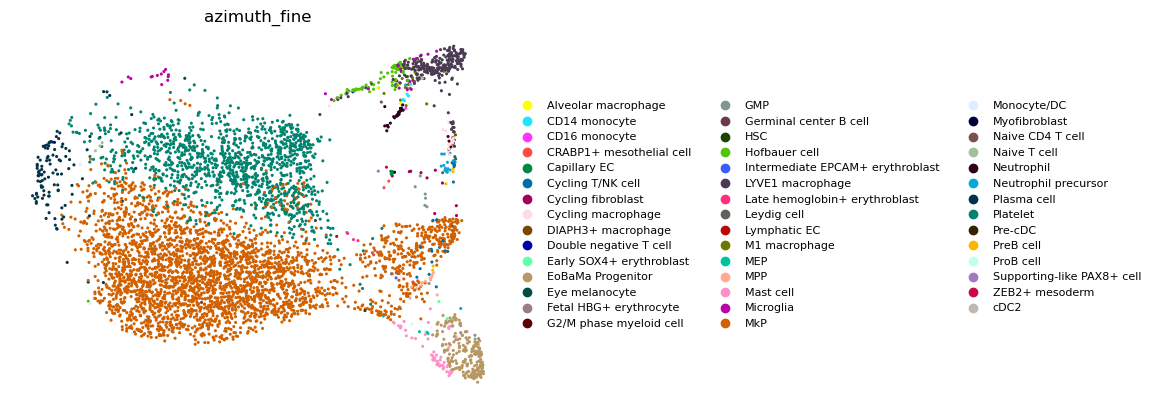

In [16]:
obj_annotated_no_false = obj_annotated[obj_annotated.obs['azimuth_fine'] != 'False', :]

sc.pl.embedding(
    obj_annotated_no_false,
    basis="azimuth_umap",
    color="azimuth_fine",
    legend_fontsize=8,
    frameon=False,
    size=20,
)

In [27]:
print(obj_annotated_no_false.obs['azimuth_fine'].cat.categories)

Index(['Alveolar macrophage', 'CD14 monocyte', 'CD16 monocyte',
       'CRABP1+ mesothelial cell', 'Capillary EC', 'Cycling T/NK cell',
       'Cycling fibroblast', 'Cycling macrophage', 'DIAPH3+ macrophage',
       'Double negative T cell', 'Early SOX4+ erythroblast',
       'EoBaMa Progenitor', 'Eye melanocyte', 'Fetal HBG+ erythrocyte',
       'G2/M phase myeloid cell', 'GMP', 'Germinal center B cell', 'HSC',
       'Hofbauer cell', 'Intermediate EPCAM+ erythroblast', 'LYVE1 macrophage',
       'Late hemoglobin+ erythroblast', 'Leydig cell', 'Lymphatic EC',
       'M1 macrophage', 'MEP', 'MPP', 'Mast cell', 'Microglia', 'MkP',
       'Monocyte/DC', 'Myofibroblast', 'Naive CD4 T cell', 'Naive T cell',
       'Neutrophil', 'Neutrophil precursor', 'Plasma cell', 'Platelet',
       'Pre-cDC', 'PreB cell', 'ProB cell', 'Supporting-like PAX8+ cell',
       'ZEB2+ mesoderm', 'cDC2'],
      dtype='object')


In [28]:
import anndata as ad
import scanpy as sc
from pathlib import Path

# Start from the RNA modality
mouse_multiome_file = Path(
    "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/multiome_processed.h5mu"
)

mouse_multiome = mu.read_h5mu(mouse_multiome_file)
rna = mouse_multiome.mod["rna"]

# Make a clean AnnData containing RAW COUNTS in X
query = ad.AnnData(
    X=rna.layers["counts"].copy(),
    obs=rna.obs.copy(),
    var=rna.var.copy(),
)

query.obs_names = rna.obs_names.copy()
query.var_names = rna.var_names.copy()

query.obs_names_make_unique()
query.var_names_make_unique()

query_path = Path(
    "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/"
    "data/processed/mouse_liver/mouse_liver_azimuth_query.h5ad"
)

query.write_h5ad(query_path)

print(query)
print(query_path)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


AnnData object with n_obs × n_vars = 19662 × 19265
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_joint'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/mouse_liver_azimuth_query.h5ad
